# Credit Card Approval Dataset

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

## Load/read the datasets

In [11]:
root = Path.cwd()

if not (root / 'data').exists():
    root = root.parent

application_df = pd.read_csv(root / 'data' / 'application_record.csv')
credit_df = pd.read_csv(root / 'data' / 'credit_record.csv')

In [12]:
print(application_df.head())
print(credit_df.head())

        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

In [13]:
print(application_df.shape)
print(credit_df.shape)

(438557, 18)
(1048575, 3)


## Merge Datasets

In [14]:
# Merge datasets using only matching IDs
merged_df = pd.merge(application_df, credit_df, on='ID', how='inner')

In [15]:
# Preview merged dataset
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [16]:
merged_df.shape

(777715, 20)

## Remove Duplicates

In [17]:
merged_df = merged_df.drop_duplicates()

## Checking Missing Values

In [11]:
merged_df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


## Handle Missing Values

In [18]:
merged_df['OCCUPATION_TYPE'] = merged_df['OCCUPATION_TYPE'].fillna("Unknown")

In [19]:
merged_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
MONTHS_BALANCE         0
STATUS                 0
dtype: int64

## 3. Feature Engineering

### 3.1. Create essential features

#### Age column

In [20]:
merged_df['AGE'] = abs(merged_df['DAYS_BIRTH']) / 365
merged_df['AGE'] = merged_df['AGE'].astype(int)

#### Number Of Years Employed Column

In [21]:
merged_df['YEARS_EMPLOYED'] = merged_df['DAYS_EMPLOYED'] / -365
merged_df.loc[merged_df['YEARS_EMPLOYED'] < 0, 'YEARS_EMPLOYED'] = 0

In [22]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,0,C,32,12.443836
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-1,C,32,12.443836
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-2,C,32,12.443836
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-3,C,32,12.443836
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-4,C,32,12.443836


#### Convert STATUS to numeric severity measure

In [23]:
status_map = {
    'X':0,
    'C':0,
    '0':1,
    '1':2,
    '2':3,
    '3':4,
    '4':5,
    '5':6
}

merged_df['STATUS_NUM'] = merged_df['STATUS'].map(status_map)

#### Aggregate credit history per customer

In [24]:
credit_summary = merged_df.groupby("ID").agg(
    TOTAL_MONTHS=('MONTHS_BALANCE','count'),
    AVG_STATUS=('STATUS_NUM','mean'),
    MAX_STATUS=('STATUS_NUM','max')
).reset_index()

#### Create risk indicator

In [52]:
def risk_bucket(status):

    if status == 0:
        return "Low Risk"

    elif status == 1:
        return "Moderate Risk"

    elif status == 2:
        return "High Risk"

    else:
        return "Default"


credit_summary["RISK_LEVEL"] = credit_summary["MAX_STATUS"].apply(risk_bucket)

In [53]:
application_unique = merged_df.drop_duplicates(subset='ID')

In [29]:
customer_df = pd.merge(application_unique, credit_summary, on="ID")

In [30]:
customer_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,AGE,YEARS_EMPLOYED,STATUS_NUM,TOTAL_MONTHS,AVG_STATUS,MAX_STATUS,HIGH_RISK
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,0,C,32,12.443836,0,16,0.187500,2,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,0,C,32,12.443836,0,15,0.200000,2,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,2.0,0,C,58,3.106849,0,30,0.233333,1,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,0,52,8.358904,1,5,0.400000,1,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,-22,X,52,8.358904,0,5,0.000000,0,0


#### Risk distribution

/var/folders/n8/4qh19g9j7l151fp04t0qn5_80000gn/T/ipykernel_37749/2411105638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


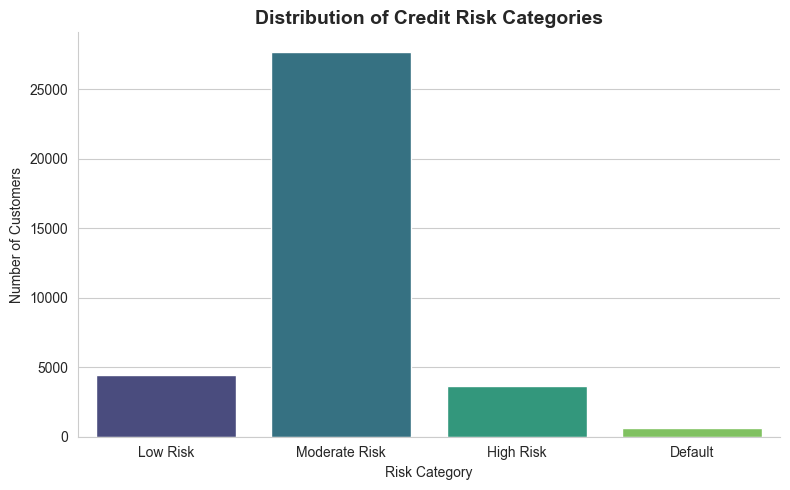

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=credit_summary,
    x="RISK_LEVEL",
    order=["Low Risk","Moderate Risk","High Risk","Default"],
    palette="viridis"
)

plt.title("Distribution of Credit Risk Categories", fontsize=14, weight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

### Risk Distribution

In [55]:
risk_dist = credit_summary["RISK_LEVEL"].value_counts(normalize=True)*100
print(risk_dist.round(2))

RISK_LEVEL
Moderate Risk    76.01
Low Risk         12.22
High Risk        10.08
Default           1.69
Name: proportion, dtype: float64


### Risk income profile

/var/folders/n8/4qh19g9j7l151fp04t0qn5_80000gn/T/ipykernel_37749/1436970804.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


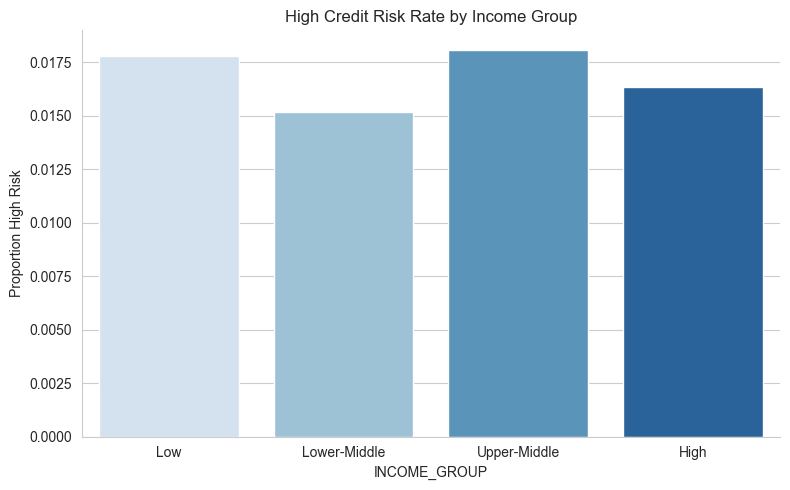

#### Income groups

In [71]:
customer_df["INCOME_GROUP_10"] = pd.qcut(
    customer_df["AMT_INCOME_TOTAL"],
    10,
    labels=[
        "LSM 1","LSM 2","LSM 3","LSM 4","LSM 5",
        "LSM 6","LSM 7","LSM 8","LSM 9","LSM 10"
    ]
)


#### Age groups

In [32]:
customer_df['AGE_GROUP'] = pd.cut(
    customer_df['AGE'],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

#### Family dependancy ratio

In [33]:
customer_df['DEPENDENCY_RATIO'] = (
    customer_df['CNT_CHILDREN'] /
    customer_df['CNT_FAM_MEMBERS']
)

## 4. Exploratory Data Analysis

### 4.1. Demographic Overview

#### A. Gender Distribution

/var/folders/n8/4qh19g9j7l151fp04t0qn5_80000gn/T/ipykernel_37749/1289935943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


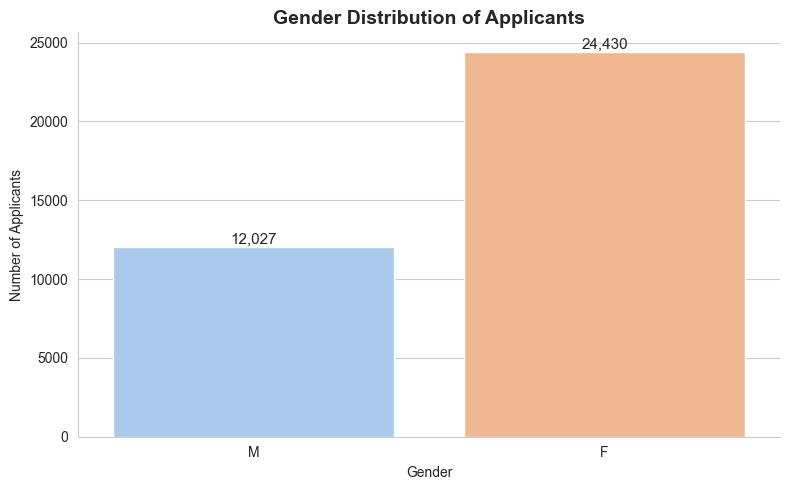

In [59]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=customer_df,
    x="CODE_GENDER",
    palette="pastel"
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Gender Distribution of Applicants", fontsize=14, weight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

sns.despine()
plt.tight_layout()
plt.show()

This shows class representation bias (Class Imbalance), of the total number of applicants,67% are Female and 33% are Male. The dataset is overfitting to women and will cause bias in approvals for either gender [evaluate which gender got more approvals].

In most credit datasets (like mortgage or business loans), men historically outnumber women. This inverse ratio (more women) strongly suggests this dataset comes from a specific domain, likely Retail Credit Cards (department stores) or Micro-finance, where women are often the primary target demographic.

#### B. Income Distribution

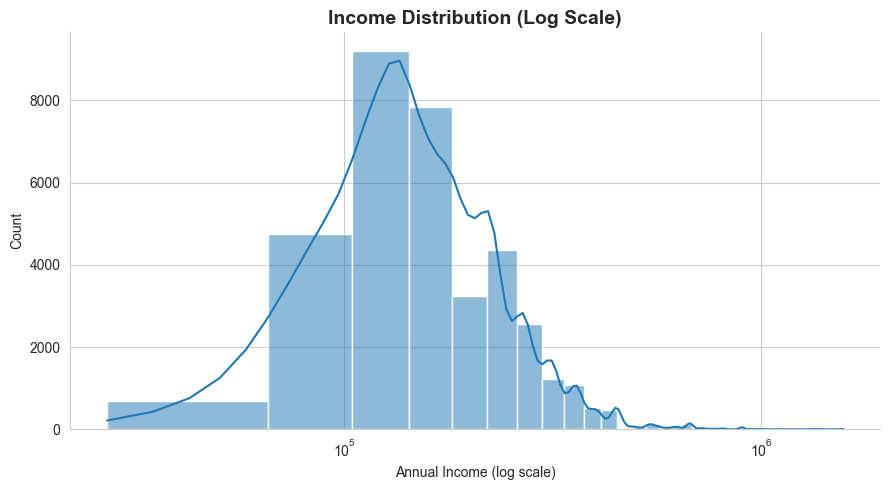

In [36]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    customer_df["AMT_INCOME_TOTAL"],
    bins=40,
    kde=True
)

ax.set_xscale("log")
ax.set_title("Income Distribution (Log Scale)", fontsize=14, weight="bold")
ax.set_xlabel("Annual Income (log scale)")
ax.set_ylabel("Count")

sns.despine()
plt.tight_layout()
plt.show()

The skewness to the right in the plot showcase a classic ***Pareto Distribution***, it indicates that a tiny minority of applicants controls a disproportionate amount of the total income wealth, while the vast majority of the applicants are clustered in the lower-to-median income range. In credit ethics, this is the "Inequality Footprint."

### 4.1 Credit risk by income profile

## 4.2. Gender Bias Analysis

### A. Income Inequality by gender

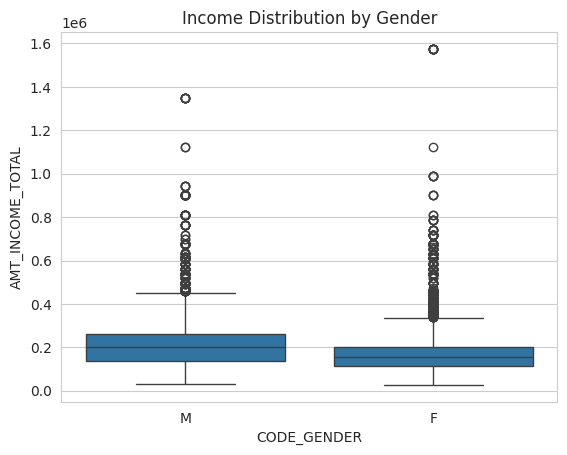

In [34]:
sns.boxplot(
    data=customer_df,
    x="CODE_GENDER",
    y="AMT_INCOME_TOTAL"
)

plt.title("Income Distribution by Gender")
plt.show()

The Male median (0.2M) is significantly higher than the Female median (approx. 0.15M). Therefore, applying a single, flat income threshold for credit approval will mathematically guarantee that a higher percentage of women is rejected as compared to men, even if we never look at the "Gender" column.

The fact that the "Max Pay" for males (0.45M) is markedly higher than for females (0.35M) illustrates the Glass Ceiling effect.
Ethical Label: This is Allocative Harm — females are systematically denied the opportunity to access higher-tier credit products solely due to structural societal factors encoded in the data. **[Generate a visual to demonstrate this]**

### B. Credit risk by gender

/var/folders/n8/4qh19g9j7l151fp04t0qn5_80000gn/T/ipykernel_37749/4193852799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


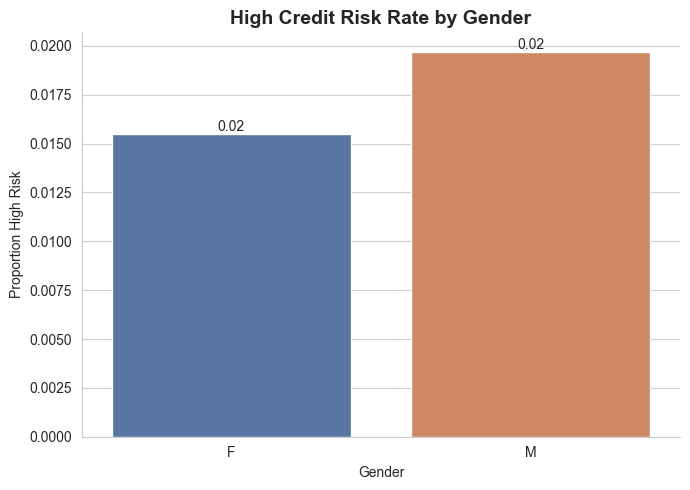

In [62]:
gender_risk = customer_df.groupby("CODE_GENDER")["HIGH_RISK"].mean().reset_index()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=gender_risk,
    x="CODE_GENDER",
    y="HIGH_RISK",
    palette=["#4C72B0", "#DD8452"]
)

ax.set_title("High Credit Risk Rate by Gender", fontsize=14, weight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion High Risk")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

sns.despine()
plt.tight_layout()
plt.show()

The data shows Males have a higher average risk rate, an automated system might rationally conclude: "Being Male is a risk factor."
This leads to Statistical Discrimination (generalizing group traits to individuals). A financially responsible male applicant could be penalized simply because other men in the dataset were reckless. **[We might adjust formula used to calculate risk to widen the gap even more]**

Is the gender gap still present once we contr

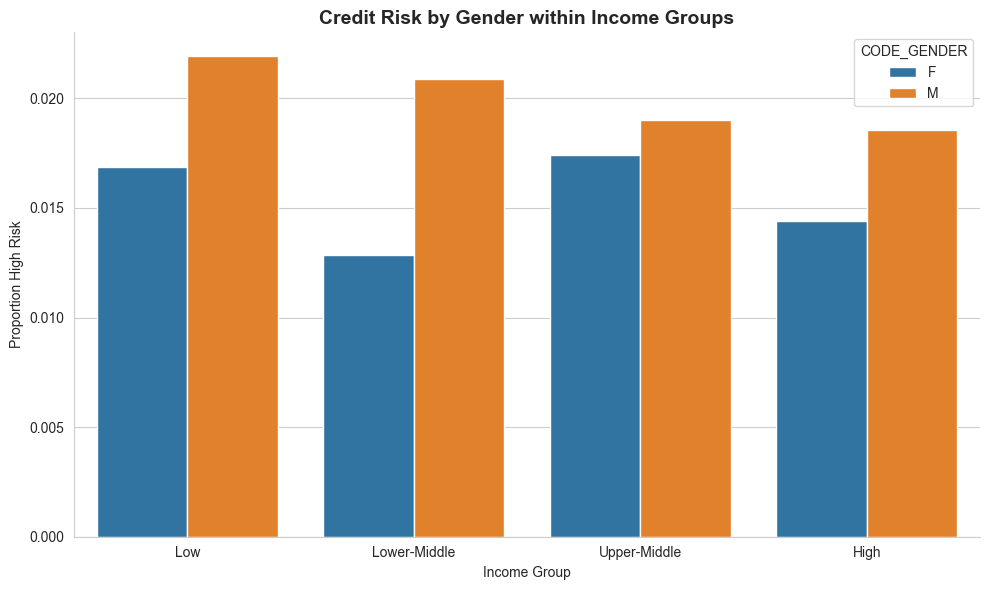

In [37]:
risk_income_gender = (
    customer_df
    .groupby(["INCOME_GROUP","CODE_GENDER"])["HIGH_RISK"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=risk_income_gender,
    x="INCOME_GROUP",
    y="HIGH_RISK",
    hue="CODE_GENDER"
)

plt.title("Credit Risk by Gender within Income Groups", fontsize=14, weight="bold")
plt.ylabel("Proportion High Risk")
plt.xlabel("Income Group")

sns.despine()
plt.tight_layout()
plt.show()

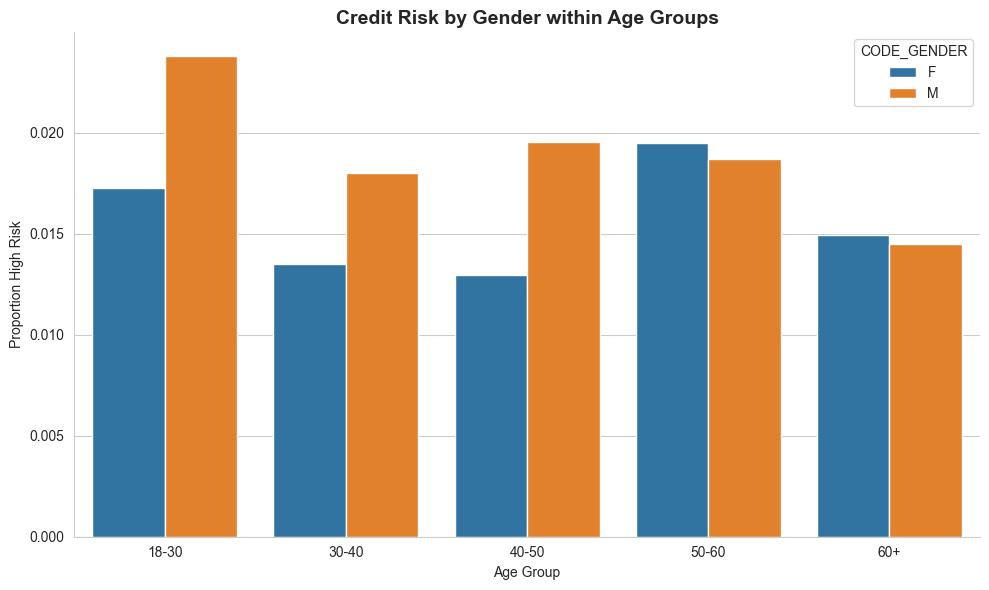

In [38]:
risk_age_gender = (
    customer_df
    .groupby(["AGE_GROUP","CODE_GENDER"])["HIGH_RISK"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=risk_age_gender,
    x="AGE_GROUP",
    y="HIGH_RISK",
    hue="CODE_GENDER"
)

plt.title("Credit Risk by Gender within Age Groups", fontsize=14, weight="bold")
plt.ylabel("Proportion High Risk")
plt.xlabel("Age Group")

sns.despine()
plt.tight_layout()
plt.show()

## 4.3. Education Privilege Analysis

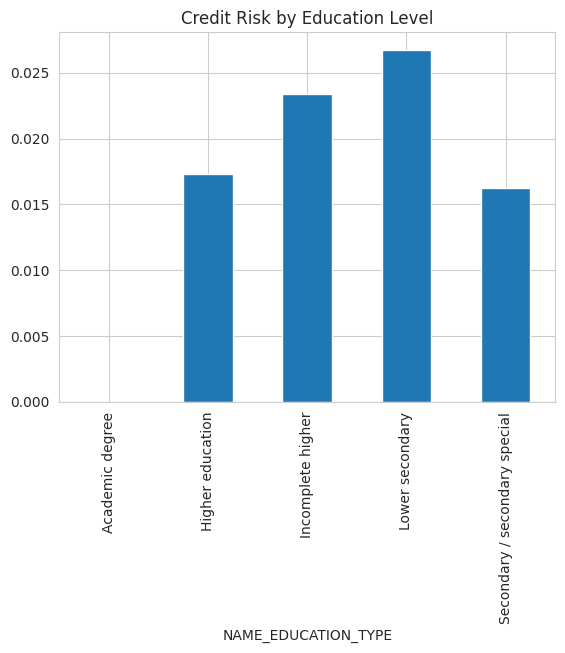

In [36]:
edu_risk = customer_df.groupby("NAME_EDUCATION_TYPE")["HIGH_RISK"].mean()

edu_risk.plot(kind="bar")
plt.title("Credit Risk by Education Level")
plt.show()

The "Zero Risk" finding for Academic Degrees is the most dangerous signal in the dataset. It represents a "Golden Ticket" Artifact — a statistical anomaly that will cause institutions to blindly approve this group while harshly penalizing everyone else.

This filters out groups that systematically face barriers to higher education but have other legit ways of generating decent income, rejecting them under the guise of "Credit Risk"

## 4.4. Occupation Bias

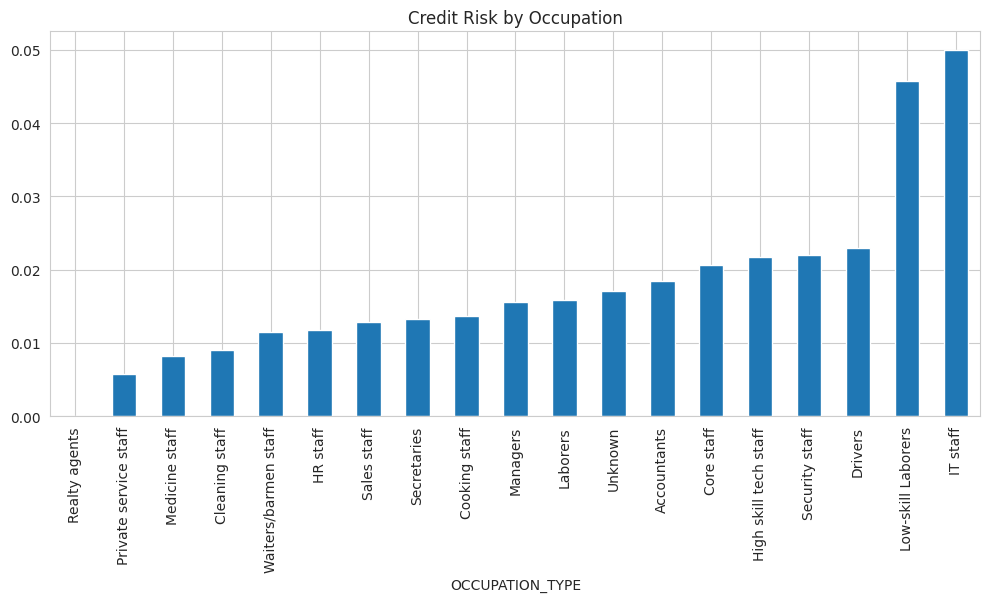

In [37]:
occ_risk = customer_df.groupby("OCCUPATION_TYPE")["HIGH_RISK"].mean().sort_values()

occ_risk.plot(kind="bar", figsize=(12,5))
plt.title("Credit Risk by Occupation")
plt.show()

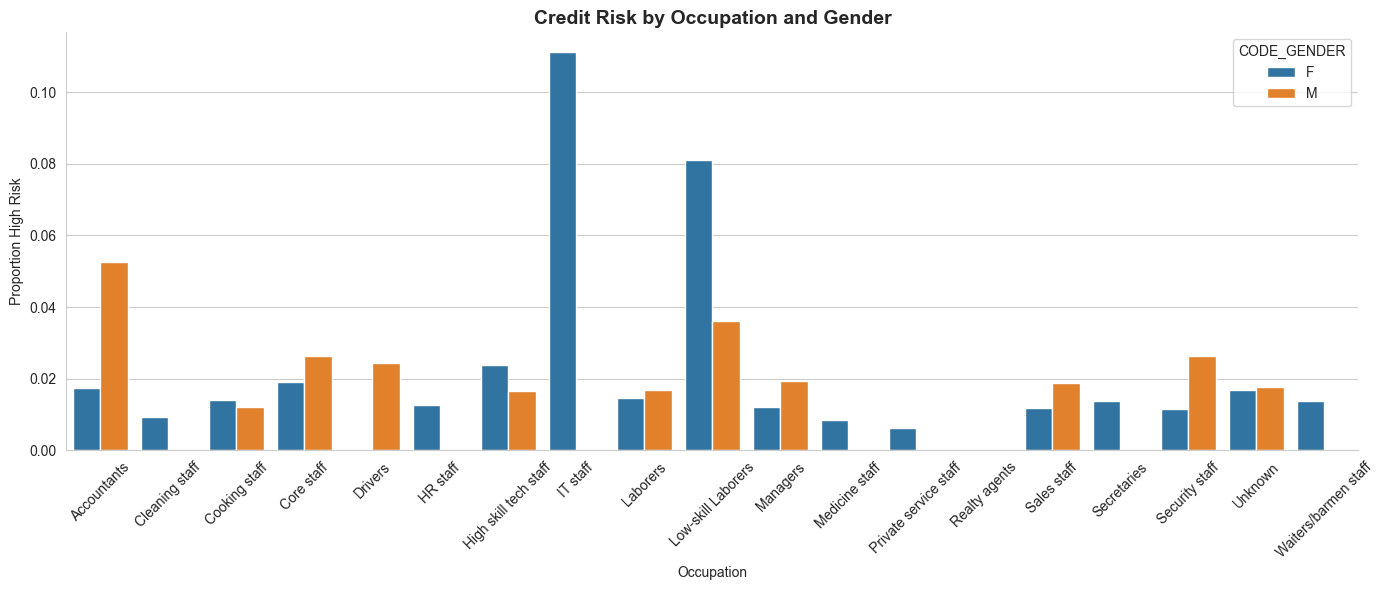

In [51]:
occ_gender_risk = (
    customer_df
    .groupby(["OCCUPATION_TYPE","CODE_GENDER"])["HIGH_RISK"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=occ_gender_risk,
    x="OCCUPATION_TYPE",
    y="HIGH_RISK",
    hue="CODE_GENDER"
)

plt.xticks(rotation=45)
plt.title("Credit Risk by Occupation and Gender", fontsize=14, weight="bold")
plt.xlabel("Occupation")
plt.ylabel("Proportion High Risk")

sns.despine()
plt.tight_layout()
plt.show()

The Zero Risk for Realty Agents is a statistical red flag ("Golden Ticket").
Temporal Bias: Real Estate is highly cyclical. If this data was collected during a property boom, Realty Agents look rich and safe. During a recession, they are the first to default.
The Danger: Using a "Boom Time" snapshot to develop company standards for credit approval that will run during a "Recession" or normal period for this industry violates the principle of Stationarity (Bostrom & Yudkowsky, 2018). You are baking a specific moment in history into the permanent logic of the institution.

## 4.5. Housing Bias

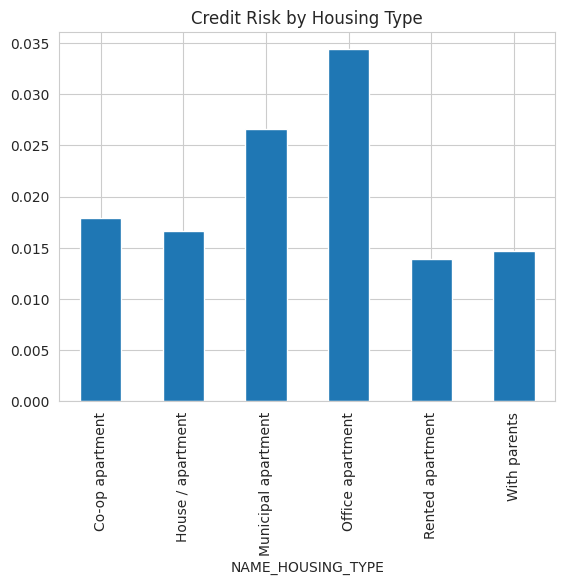

In [38]:
housing_risk = customer_df.groupby("NAME_HOUSING_TYPE")["HIGH_RISK"].mean()

housing_risk.plot(kind="bar")
plt.title("Credit Risk by Housing Type")
plt.show()

## 5. Intersectional Bias

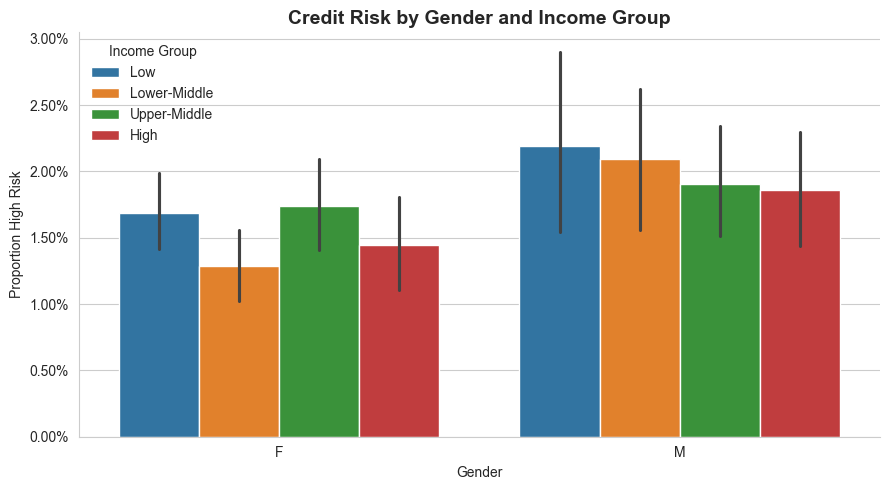

In [73]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=customer_df,
    x="CODE_GENDER",
    y="HIGH_RISK",
    hue="INCOME_GROUP",
    order=["F", "M"],
    hue_order=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

ax.set_title("Credit Risk by Gender and Income Group", fontsize=14, weight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion High Risk")

# Format y-axis as percentages
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Clean legend
ax.legend(title="Income Group", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

## 6. Racial Biases

### 6.1. Generate sysnthetic race data using Probability assumptions (income and occupation correlations)

NOTE: The basis of figures/assumptions used here can change, we need to use reliable source for racial income distribution in south africa

In [42]:
np.random.seed(42)

def assign_race(row):

    # High risk customers
    if row['HIGH_RISK'] == 1:
        return np.random.choice(
            ['Coloured','Black','Indian','White'],
            p=[0.40, 0.35, 0.20, 0.05]
        )

    # Low risk customers
    else:
        return np.random.choice(
            ['White','Indian','Black','Coloured'],
            p=[0.50, 0.25, 0.15, 0.10]
        )

customer_df['RACE'] = customer_df.apply(assign_race, axis=1)

## 7. Race Bias Analysis

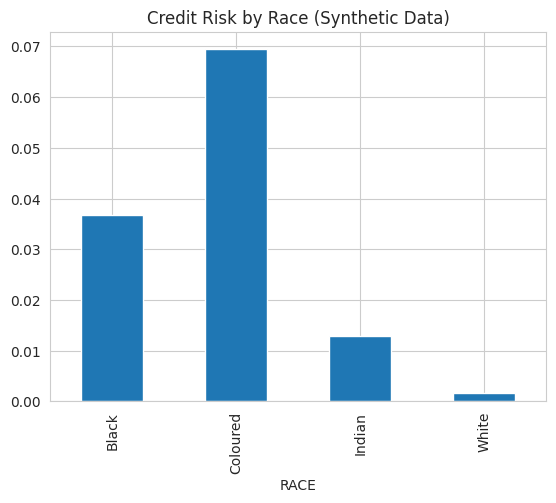

In [43]:
race_risk = customer_df.groupby("RACE")["HIGH_RISK"].mean()

race_risk.plot(kind="bar")
plt.title("Credit Risk by Race (Synthetic Data)")
plt.show()

White applicants having ~0% risk while Coloured applicants have the highest **[Important point for presentation]**

Since we generated this Race column using other variables (likely Housing, Education, Income...), this chart does not prove that "White people pay better." It proves **Transitivity**: The original variables (Income, Education, Housing...) were already so heavily stratified that when we used them to predict Race in the sythetic data generation, we effectively rebuilt the apartheid-era economic hierarchy. The "Zero Risk" for White applicants is the mathematical proof that our credit scoring system is protecting privilege, not assessing individual character.

These insights show that the company is not judging creditworthiness; it is judging Social Capital. This violates the ethical principle of Justice (Vallor & Rewark, 2018) by treating a historical advantage as a moral merit.

The fact that Coloured applicants show the highest risk (even higher than Black applicants) highlights the nuance of Intersectionality.
In the South African context (implied by "Rands" and "Coloured"), this group often sits in a specific economic band—perhaps urban working class with "Secondary" education (which you identified earlier as High Risk). If the enterprise uses this insight to inform decisions, it will disproportionately deny credit to this specific community, stripping them of economic mobility. This is Feedback Loop Amplification (Bostrom & Yudkowsky, 2018)—the data reflects past struggle, and the decision ensures future struggle.

# References

[1] M. Ahmed, “Credit Card Approval Prediction Notebook Dataset,” Kaggle. [Online]. Available: https://www.kaggle.com/code/mennaahmed016/credit-card-approval-prediction-notebook/input
. Accessed: Mar. 5, 2026.

[2] F. Martínez-Plumed et al., “CRISP-DM twenty years later: From data mining processes to data science trajectories,” IEEE Transactions on Knowledge and Data Engineering, vol. 33, no. 8, pp. 3048–3061, Aug. 2021.

[3] OpenAI, “ChatGPT,” OpenAI. [Online]. Available: https://chat.openai.com
. Accessed: Mar. 3, 2026.